# DATASET: human_vital_signs_dataset_2024
**<u>Objetivo</u>:**

---------

El sistema necesita identificar automáticamente cuando los signos vitales (ritmo cardiaco, oxigenación y temperatura) indican que un paciente está entrando en un estado de riesgo. Se realizara un modelo entrenado que

In [ ]:
# Importar librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score, roc_curve, roc_auc_score

import warnings
warnings.filterwarnings("ignore")

In [5]:
# Importar dataset
df = pd.read_csv("dataset_cardiogo.csv")

df

,EDAD,RITMO_CARDIACO,OXIGENACION,TEMPERATURA,OUTPUT
0,22,101.71,94.76,36.79,0
1,20,84.86,95.69,36.95,0
2,89,55.71,96.65,36.42,1
3,47,86.81,98.18,36.66,0
4,19,53.97,98.30,37.13,1
...,...,...,...,...,...
12999,45,74.46,95.15,37.01,0
13000,79,97.33,96.37,36.30,1
13001,92,70.76,95.46,37.22,1
13002,90,74.51,99.71,36.84,1


In [254]:
# Información general
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13004 entries, 0 to 13003
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   EDAD            13004 non-null  int64  
 1   RITMO_CARDIACO  13004 non-null  float64
 2   OXIGENACION     13004 non-null  float64
 3   TEMPERATURA     13004 non-null  float64
 4   OUTPUT          13004 non-null  int64  
dtypes: float64(3), int64(2)
memory usage: 508.1 KB
None


In [255]:
# Resumen estadístico
print(df.describe())


               EDAD  RITMO_CARDIACO   OXIGENACION   TEMPERATURA        OUTPUT
count  13004.000000    13004.000000  13004.000000  13004.000000  13004.000000
mean      61.216395       82.180682     96.854511     36.697258      0.500000
std       23.205171       14.856655      1.802715      0.350250      0.500019
min       18.000000       40.000000     90.440000     35.270000      0.000000
25%       41.000000       72.317500     95.640000     36.460000      0.000000
50%       64.000000       82.190000     96.930000     36.700000      0.500000
75%       82.000000       92.042500     98.160000     36.940000      1.000000
max       94.000000      137.240000    100.000000     38.050000      1.000000


In [256]:
# Normalizar nombres de columnas
df.columns = df.columns.str.strip().str.upper().str.replace(" ", "_")

df.head()


,EDAD,RITMO_CARDIACO,OXIGENACION,TEMPERATURA,OUTPUT
0,22,101.71,94.76,36.79,0
1,20,84.86,95.69,36.95,0
2,89,55.71,96.65,36.42,1
3,47,86.81,98.18,36.66,0
4,19,53.97,98.30,37.13,1


In [257]:
# Valores nulos
df.isnull().sum()

EDAD              0
RITMO_CARDIACO    0
OXIGENACION       0
TEMPERATURA       0
OUTPUT            0
dtype: int64

In [258]:
# Como hay valores nulos se hara una limpia


In [259]:
# Valores nulos
df.isnull().sum()

EDAD              0
RITMO_CARDIACO    0
OXIGENACION       0
TEMPERATURA       0
OUTPUT            0
dtype: int64

In [260]:
# df.groupby("OUTPUT")[["HR_(BPM)", "SPO2_(%)", "TEMP_(*C)"]].mean()


In [261]:
# # Crear umbrales basados en percentiles del dataset
# hr_thresh = df["HEART_RATE"].quantile(0.90)
# spo2_thresh = df["OXYGEN_SATURATION"].quantile(0.10)
# temp_thresh = df["BODY_TEMPERATURE"].quantile(0.90)

# # Crear etiqueta de riesgo con esos percentiles
# df["RISK_CATEGORY"] = (
#     (df["HEART_RATE"] > hr_thresh) |
#     (df["OXYGEN_SATURATION"] < spo2_thresh) |
#     (df["BODY_TEMPERATURE"] > temp_thresh)
# ).astype(int)

# print(df["RISK_CATEGORY"].value_counts())

# print(df.head())
# print(df.columns)
# print(df.dtypes)


In [262]:
# Asegurar que Risk Category esté en binario: Low=0, High=1
# df["OUTPUT"] = df["OUTPUT"].replace({"Normal": 0, "Abnormal": 1})

print(df["OUTPUT"].value_counts())

# # Seleccionar solo variables relevantes para tu prototipo
df_model = df[["EDAD", "RITMO_CARDIACO", "OXIGENACION", "TEMPERATURA", "OUTPUT"]]

df_model

OUTPUT
0    6502
1    6502
Name: count, dtype: int64


,EDAD,RITMO_CARDIACO,OXIGENACION,TEMPERATURA,OUTPUT
0,22,101.71,94.76,36.79,0
1,20,84.86,95.69,36.95,0
2,89,55.71,96.65,36.42,1
3,47,86.81,98.18,36.66,0
4,19,53.97,98.30,37.13,1
...,...,...,...,...,...
12999,45,74.46,95.15,37.01,0
13000,79,97.33,96.37,36.30,1
13001,92,70.76,95.46,37.22,1
13002,90,74.51,99.71,36.84,1


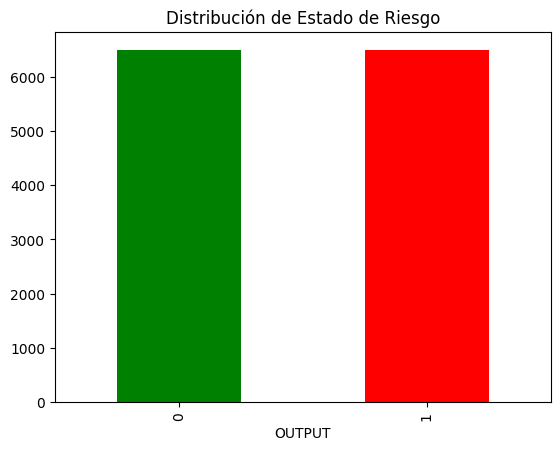

In [263]:
# Distribucion Objetivo
df_model["OUTPUT"].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title("Distribución de Estado de Riesgo")
plt.show()


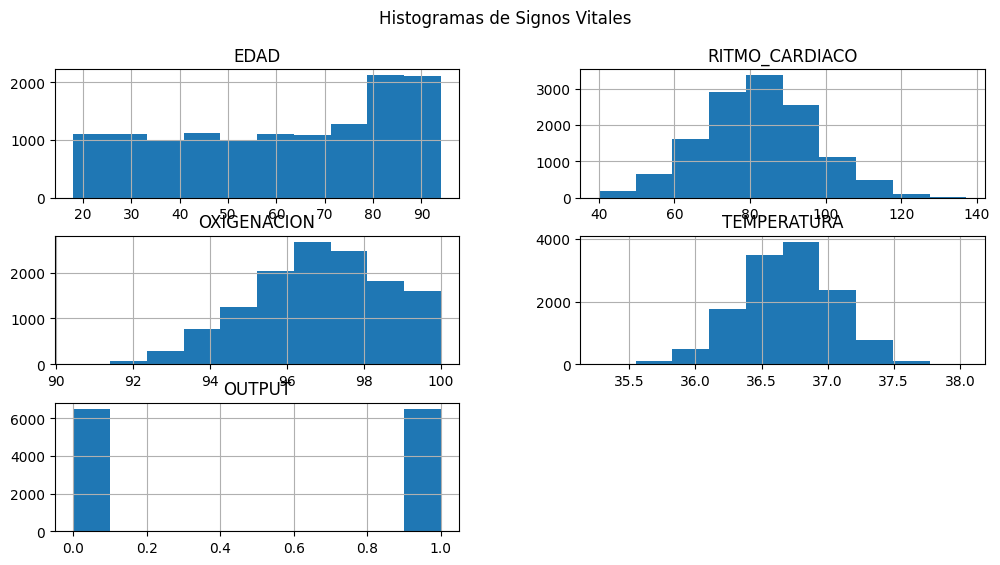

In [264]:
# Histogramas
df_model.hist(figsize=(12, 6))
plt.suptitle("Histogramas de Signos Vitales")
plt.show()


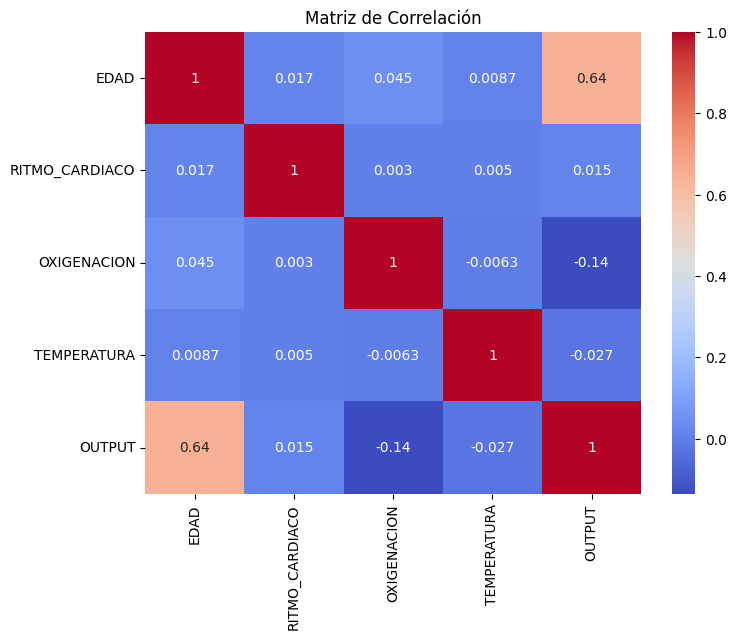

In [265]:
# Mapa de correlacion
plt.figure(figsize=(8, 6))
sns.heatmap(df_model.corr(), annot=True, cmap="coolwarm")
plt.title("Matriz de Correlación")
plt.show()


In [266]:
# Variables predictoras
X = df_model.drop("OUTPUT", axis=1)

# Variable objetivo
y = df_model["OUTPUT"]

# División entrenamiento/prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# from imblearn.over_sampling import SMOTE

# sm = SMOTE()
# X_res, y_res = sm.fit_resample(X, y)

# X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [267]:
# Creacion del modelo
modelo = LogisticRegression()

modelo.fit(X_train_scaled, y_train)

y_pred = modelo.predict(X_test_scaled)


In [268]:
# Matriz de confusion
cm = confusion_matrix(y_test, y_pred)
cm


array([[1016,  302],
       [ 199, 1084]])

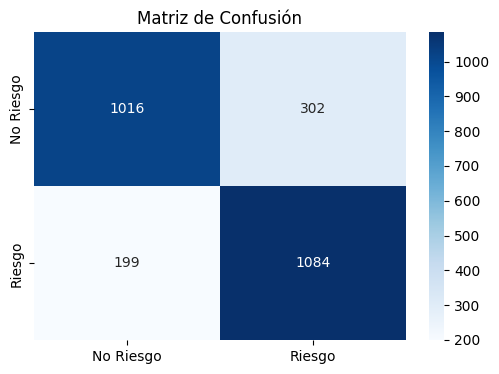

In [269]:
# Matriz de Confusión
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Riesgo", "Riesgo"], 
            yticklabels=["No Riesgo", "Riesgo"])
plt.title("Matriz de Confusión")
plt.show()



In [270]:
# Métricas
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("MÉTRICAS DEL MODELO:")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precisión: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print("\nReporte Completo:\n")
print(classification_report(y_test, y_pred))

MÉTRICAS DEL MODELO:
Accuracy:  0.8074
Precisión: 0.7821
Recall:    0.8449
F1-Score:  0.8123

Reporte Completo:

              precision    recall  f1-score   support

           0       0.84      0.77      0.80      1318
           1       0.78      0.84      0.81      1283

    accuracy                           0.81      2601
   macro avg       0.81      0.81      0.81      2601
weighted avg       0.81      0.81      0.81      2601



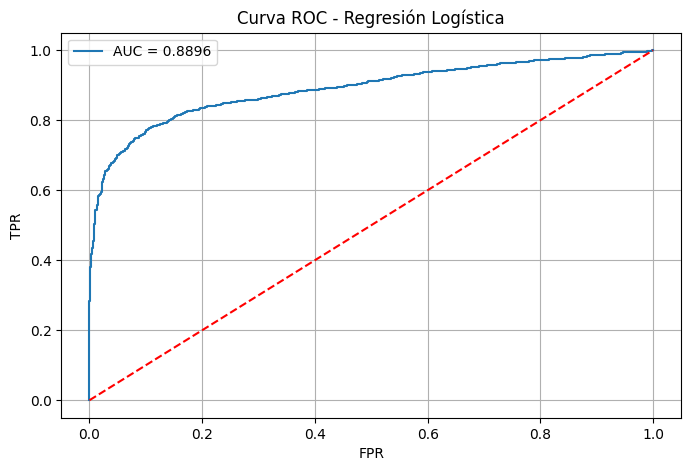

In [271]:
y_pred_proba = modelo.predict_proba(X_test_scaled)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(8,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
plt.plot([0,1],[0,1], linestyle="--", color="red")
plt.title("Curva ROC - Regresión Logística")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.grid()
plt.show()


In [272]:
# Escalar datos

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)

print("MÉTRICAS DEL MODELO:")
print(f"Accuracy:  {accuracy_knn:.4f}")
print(f"Precisión: {precision_knn:.4f}")
print(f"Recall:    {recall_knn:.4f}")
print(f"F1-Score:  {f1_knn:.4f}")
print(classification_report(y_test, y_pred_knn))


MÉTRICAS DEL MODELO:
Accuracy:  0.9604
Precisión: 0.9504
Recall:    0.9704
F1-Score:  0.9603
              precision    recall  f1-score   support

           0       0.97      0.95      0.96      1318
           1       0.95      0.97      0.96      1283

    accuracy                           0.96      2601
   macro avg       0.96      0.96      0.96      2601
weighted avg       0.96      0.96      0.96      2601



In [273]:
print("Comparación de modelos:")
print(f"Reg Logistic -> Recall: {recall:.4f}, F1: {f1:.4f}")
print(f"KNN          -> Recall: {recall_score(y_test, y_pred_knn):.4f}, F1: {f1_score(y_test, y_pred_knn):.4f}")


Comparación de modelos:
Reg Logistic -> Recall: 0.8449, F1: 0.8123
KNN          -> Recall: 0.9704, F1: 0.9603


In [280]:
# Eliminar modelos previos si existen
for archivo in ["modelo_riesgo_cardiaco.pkl", "scaler_riesgo.pkl"]:
    if os.path.exists(archivo):
        os.remove(archivo)
        print(f"Archivo eliminado: {archivo}")

print("COMPARACIÓN DE MODELOS:")
print(f"Regresión Logística -> Recall: {recall:.4f}, F1: {f1:.4f}")
print(f"KNN -> Recall: {recall_knn:.4f}, F1: {f1_knn:.4f}")


Archivo eliminado: modelo_riesgo_cardiaco.pkl
Archivo eliminado: scaler_riesgo.pkl
COMPARACIÓN DE MODELOS:
Regresión Logística -> Recall: 0.8449, F1: 0.8123
KNN -> Recall: 0.9704, F1: 0.9603


In [ ]:
# Selección del mejor modelo
if (recall_knn > recall) or (recall_knn == recall and f1_knn > f1):
    mejor_modelo = knn
    modelo_nombre = "KNN"
    joblib.dump(mejor_modelo, "modelo_riesgo_cardiaco.pkl")

else:
    mejor_modelo = modelo
    modelo_nombre = "Regresión Logística"
    joblib.dump(mejor_modelo, "modelo_riesgo_cardiaco.pkl")

joblib.dump({'scaler': scaler, 'feature_names': list(X.columns)}, "scaler_riesgo.pkl")

print(f"\nModelo seleccionado: {modelo_nombre}")
print("Modelo guardado correctamente.")



Modelo seleccionado: Regresión Logística
Modelo guardado correctamente.


In [9]:
# SISTEMA DE PREDICIÓN
class SistemaPrediccionRiesgo:
    def __init__(self, modelo_path):
        self.modelo = joblib.load(modelo_path)
        self.scaler = None
        self.feature_names = None
        self.umbral_confianza = 0.6

        # Intentar cargar scaler
        try:
            data = joblib.load("scaler_riesgo.pkl")
            self.scaler = data['scaler']
            self.feature_names = data['feature_names']
            print("Scaler cargado correctamente.")
        except:
            print("Scaler no encontrado. Se usará el modelo sin escalar.")

    def analizar_paciente(self, signos):
        df = pd.DataFrame([signos])

        # Si el scaler existe → aplicar orden y transformación
        if self.scaler is not None and self.feature_names is not None:
            # Ordenar columnas
            df = df[self.feature_names]
            df_proc = self.scaler.transform(df)
        else:
            # Usar los datos directamente sin escalar
            df_proc = df.values

        # Predicción
        proba = self.modelo.predict_proba(df_proc)[0]
        pred = int(self.modelo.predict(df_proc)[0])
        confianza = proba[pred]

        # Interpretación
        if pred == 1 and confianza >= self.umbral_confianza:
            resultado = "RIESGO ALTO - requiere atención inmediata"
        elif pred == 1:
            resultado = "RIESGO MODERADO - monitoreo recomendado"
        else:
            resultado = "Riesgo bajo - signos normales"

        return {
            "prediccion": int(pred),
            "probabilidad": float(proba[1]),
            "confianza": float(confianza),
            "resultado": resultado
        }


In [12]:
# PRUEBA DEL SISTEMA
sistema = SistemaPrediccionRiesgo("modelo_riesgo_cardiaco.pkl")

pacientes = [
    {"RITMO_CARDIACO": 210, "OXIGENACION": 80,  "TEMPERATURA": 40, "EDAD": 35},
    {"RITMO_CARDIACO": 65, "OXIGENACION": 98, "TEMPERATURA": 34.91, "EDAD": 40},
    # {"RITMO_CARDIACO": 98, "OXIGENACION": 94, "TEMPERATURA": 37.8, "EDAD": 35},
    {"RITMO_CARDIACO": 110, "OXIGENACION": 96, "TEMPERATURA": 38.4, "EDAD": 35},
    {"RITMO_CARDIACO": 120, "OXIGENACION": 89, "TEMPERATURA": 36.9, "EDAD": 35},
    {"RITMO_CARDIACO": 115, "OXIGENACION": 94, "TEMPERATURA": 37.4, "EDAD": 35}
]

for i, p in enumerate(pacientes, 1):
    r = sistema.analizar_paciente(p)
    print(f"\nPaciente {i}:")
    print(f"Probabilidad de riesgo: {r['probabilidad']:.2%}")
    print(f"Confianza del modelo: {r['confianza']:.2%}")
    print(f"Resultado: {r['resultado']}")

Scaler cargado correctamente.

Paciente 1:
Probabilidad de riesgo: 93.81%
Confianza del modelo: 93.81%
Resultado: RIESGO ALTO - requiere atención inmediata

Paciente 2:
Probabilidad de riesgo: 14.88%
Confianza del modelo: 85.12%
Resultado: Riesgo bajo - signos normales

Paciente 3:
Probabilidad de riesgo: 7.53%
Confianza del modelo: 92.47%
Resultado: Riesgo bajo - signos normales

Paciente 4:
Probabilidad de riesgo: 60.12%
Confianza del modelo: 60.12%
Resultado: RIESGO ALTO - requiere atención inmediata

Paciente 5:
Probabilidad de riesgo: 18.54%
Confianza del modelo: 81.46%
Resultado: Riesgo bajo - signos normales
